# Exercise 1

a)

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{a}^T,
$$


$$
\boldsymbol{a}^T\boldsymbol{x} = [a_1 x_1  \space a_2 x_2 \space .... \space a_n x_n]
$$

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = {\nabla}_x (a^T x) = [ \frac{\partial (\boldsymbol{a_1}\boldsymbol{x_1})}{\partial \boldsymbol{x}} \space \frac{\partial (\boldsymbol{a_2}\boldsymbol{x_2})}{\partial \boldsymbol{x}} \space ..... \space \frac{\partial (\boldsymbol{a_n}\boldsymbol{x_n})}{\partial \boldsymbol{x}}]
$$

$$
= [a_1 \space a_2 \space ..... \space a_n] = a^T
$$

b)

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right),
$$

Her er $\boldsymbol{a}$ en vektor med lengde n, og $\boldsymbol{A}$ er en matrise med dimensjoner n x n.
Dette gjør at vi kan skrive $\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a}$ som en sum slik:

$$
\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a} = \sum_{i=0}^{n-1} \sum_{j=0}^{n-1} a_{i} b_{ij} a_{j}
$$
Kallar elementene i $\boldsymbol{A}$ for $b_{ij}$
$\\$
Hvis vi tar den deriverte med hensyn på element $a_k$ i $\boldsymbol{a}$ kan vi bruke produktregelen:

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial a_k} = \sum_{i=0}^{n-1} a_{i} b_{ik} + \sum_{j=0}^{n-1} a_{j} b_{kj}
$$
der k = 0, 1, 2, ....., n-1

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T \boldsymbol{A} + \boldsymbol{a}^T \boldsymbol{A}^T = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right)
$$

c)

$$
\frac{\partial \left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}} = -2\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\boldsymbol{A}
$$

Definerer en funksjon $f(\boldsymbol{s})$ og en matrise $\boldsymbol{w}$
$$
f(\boldsymbol{s}) = (\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})^T (\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}) = \sum_{i=0}^{n-1} (\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})^2
$$
$$
\boldsymbol{w} = \boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}
$$
=>
$$
f(\boldsymbol{s}) = \boldsymbol{w}^T \boldsymbol{w}
$$

$$
\frac{\partial f(\boldsymbol{s})}{\partial \boldsymbol{s}} = 2 \boldsymbol{w}^T \frac{\partial \boldsymbol{w}}{\partial \boldsymbol{s}}
$$

Bruker at:
$$
\frac{\partial \boldsymbol{w}}{\partial \boldsymbol{s}} = - \boldsymbol{A}
$$
=>
$$
\frac{\partial f(\boldsymbol{s})}{\partial \boldsymbol{s}} = - 2 (\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})^T A
$$

Finne andrederiverte:
$\\$
Begynner med å skrive om den deriverte med hensyn på $\boldsymbol{s}^T$

$$
\frac{\partial f(\boldsymbol{s})}{\partial \boldsymbol{s}^T} = - 2 \boldsymbol{A}^T(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})
$$
$$
\frac{\partial }{\partial \boldsymbol{s}} \frac{\partial f(\boldsymbol{s})}{\partial \boldsymbol{s^T}} = \frac{\partial }{\partial \boldsymbol{s}} [- 2 \boldsymbol{A}^T(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})] = 2 \boldsymbol{A}^T \boldsymbol{A}
$$

Der
$$
\boldsymbol{A}^T \boldsymbol{A} = \boldsymbol{H}
$$
Er Hessian matrisen $\boldsymbol{H}$

# Exercise 2

1.

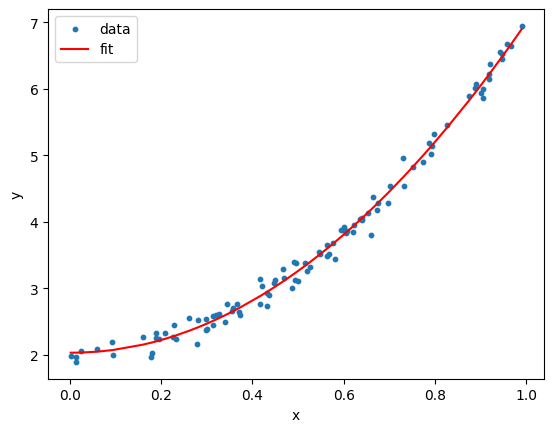

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
x = rng.random((100, 1))
y = 2.0 + 5.0 * x * x + 0.1 * rng.standard_normal((100, 1))

X = np.zeros((100, 3))

for j in range(3):
    X[:,j] = x.flatten()**j

theta = np.linalg.inv(X.T @ X) @ X.T @ y
y_tilde = X @ theta

x_sorted_idx = np.argsort(x.flatten())
plt.scatter(x, y, s=10, label="data")
plt.plot(x.flatten()[x_sorted_idx], y_tilde.flatten()[x_sorted_idx], color="red", label="fit")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

2.

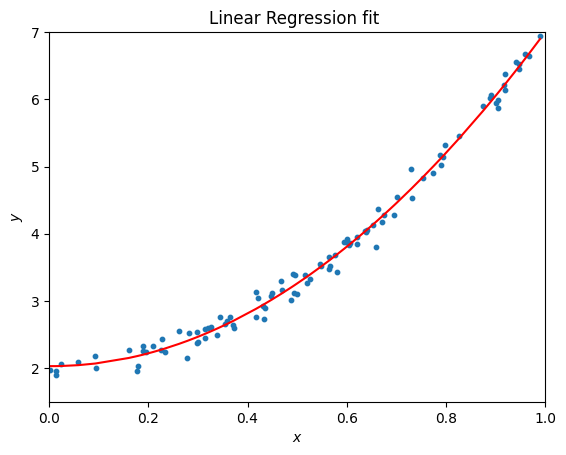

In [2]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X,y)
y_tilde_sklearn = linreg.predict(X)


plt.scatter(x, y, s=10, label="data")
plt.plot(x.flatten()[x_sorted_idx], y_tilde_sklearn.flatten()[x_sorted_idx],'r-')
plt.axis([0.0,1.0,1.5, 7.0])
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Linear Regression fit ')
plt.show()

3.

In [4]:
from sklearn.metrics import mean_squared_error, r2_score

# The mean squared error    
print("Mean squared error using own function:", mean_squared_error(y, y_tilde))                           
print("Mean squared error using sklearn:", mean_squared_error(y, y_tilde_sklearn))

# Explained variance score: 1 is perfect prediction   
print('R^2 score using own function:', r2_score(y, y_tilde))                              
print('R^2 score using sklearn:', r2_score(y, y_tilde_sklearn))

Mean squared error using own function: 0.013728156746263008
Mean squared error using sklearn: 0.013728156746263003
R^2 score using own function: 0.9928732429893427
R^2 score using sklearn: 0.9928732429893427


Discussion of results:

# Exercise 3

1.

In [6]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

n = 100
x3 = np.linspace(-3, 3, n).reshape(-1, 1)
y3 = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)

X3 = np.zeros((n,6)) # fifth order polynomial

for j in range(6):
    X3[:,j] = x3.flatten()**j


X3_train, X3_test, y3_train, y3_test, x3_train, x3_test = train_test_split(X3, y3, x3, test_size=0.33, random_state=42)



2.

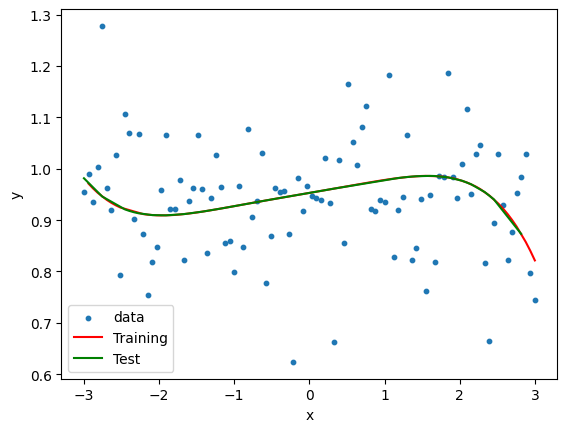

In [ ]:
from sklearn.linear_model import LinearRegression

OLS = LinearRegression()
OLS.fit(X3_train,y3_train)

y_tilde_train = OLS.predict(X3_train) # fitting the model to training data
y_tilde_test = OLS.predict(X3_test) # fitting the model to test data

# Need to sort elements in order from low to high values to prevent zigzag model-graphs in plot. 
# Argsort gives the indices that gives this order, which is then used to sort the elements in the array  
x3_train_idx = np.argsort(x3_train.flatten()) # sorted indexes based on training input x 
x3_test_idx = np.argsort(x3_test.flatten()) # sorted indexes based on test input x

plt.scatter(x3, y3, s=10, label="data") # plottet data as points
plt.plot(x3_train.flatten()[x3_train_idx], y_tilde_train.flatten()[x3_train_idx], color="red", label="Training")
plt.plot(x3_test.flatten()[x3_test_idx], y_tilde_test.flatten()[x3_test_idx], color="green", label="Test")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

scikit-learn does not include the intercept by default — see the discussions on scaling, and implement?

In [13]:
from sklearn.metrics import mean_squared_error

print("Mean squared error for training data:", mean_squared_error(y3_train, y_tilde_train))
print("Mean squared error for test data:", mean_squared_error(y3_test, y_tilde_test))

Mean squared error for training data: 0.009890428587637444
Mean squared error for test data: 0.016629507219776157


3.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def model_poly(x,y,degree):
    n = len(x)
    X = np.zeros((n,degree+1))
    
    for j in range(degree+1):
        X[:,j] = x.flatten()**j

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

    OLS = LinearRegression()
    OLS.fit(X_train,y_train) 

    y_predict_train = OLS.predict(X_train)
    y_predict_test = OLS.predict(X_test)

    mse_train = mean_squared_error(y_train, y_predict_train)
    mse_test = mean_squared_error(y_test, y_predict_test)

    return mse_train, mse_test

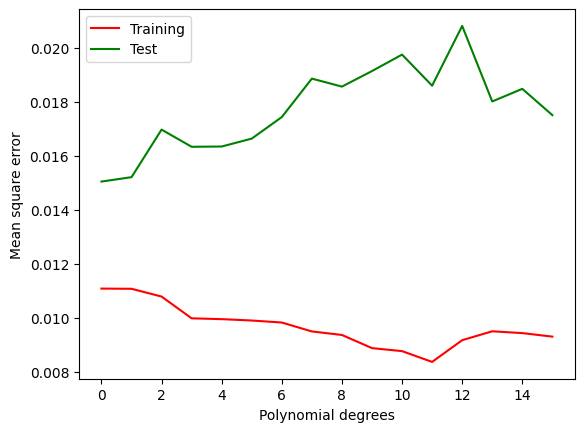

In [16]:
import matplotlib.pyplot as plt

degrees = np.arange(0,16)
mse_train_array = np.zeros(len(degrees))
mse_test_array = np.zeros(len(degrees))

for i in degrees:
    mse_train_array[i], mse_test_array[i] = model_poly(x3,y3,i)

plt.plot(degrees, mse_train_array, color="red", label="Training")
plt.plot(degrees, mse_test_array, color="green", label="Test")
plt.xlabel("Polynomial degrees")
plt.ylabel("Mean square error")
plt.legend()
plt.show()

In [17]:
min_index_train = np.where(mse_train_array == min(mse_train_array))
# can just use the index, as index (0,16) and polynomial degree (0,16)
print(f'the optimal polynomial degree for training data is:', min_index_train[0][0])

min_index_test = np.where(mse_test_array == min(mse_test_array))
print(f'the optimal polynomial degree for test data is:',min_index_test[0][0])

the optimal polynomial degree for training data is: 11
the optimal polynomial degree for test data is: 0


Discussion of result: plot ser litt sus ut, sjekk ut dette!

Bruker metode fra uke 35 tirsdag slides istedet:

In [21]:
def MSE(y_data, y_model):
    return np.mean((y_data - y_model) ** 2)

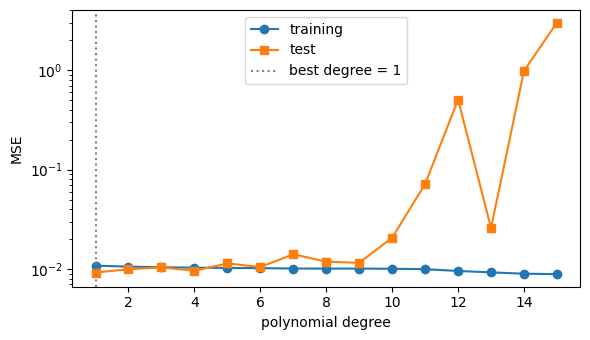

best OLS test MSE 0.00922 at degree 1


In [22]:
n = 100
x3 = np.linspace(-3, 3, n).reshape(-1, 1)
y3 = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)

x_train, x_test, y_train, y_test = train_test_split(x3, y3, test_size=0.3,random_state=2026)

# 1. OLS: training and test MSE against polynomial degree
degrees = range(1, 16)
mse_train, mse_test = [], []
for d in degrees: # runs through degrees 1-15
    # np.vander creates a matrix where the columns are the power of the input vector, increasing power in this case
    Xtr = np.vander(x_train.flatten(), d + 1, increasing=True) # d + 1 is the number of columns
    Xte = np.vander(x_test.flatten(),  d + 1, increasing=True)

    theta = np.linalg.lstsq(Xtr, y_train, rcond=None)[0] # gives the theta parameters based on given polynomial degree in the design matrix
    mse_train.append(MSE(y_train, Xtr @ theta)) # inputs in MSE (known y data, predicted y datas based on model)
    mse_test.append(MSE(y_test,  Xte @ theta))

best_d = degrees[int(np.argmin(mse_test))] # finds the index = degree that has the lowest MSE in test data
plt.figure(figsize=(6, 3.5))
plt.plot(degrees, mse_train, "o-", label="training") # plotting mean square error over degrees
plt.plot(degrees, mse_test, "s-", label="test")
plt.axvline(best_d, color="gray", ls=":", label=f"best degree = {best_d}")
plt.xlabel("polynomial degree"); plt.ylabel("MSE"); plt.yscale("log"); plt.legend()
plt.tight_layout(); plt.show()
print(f"best OLS test MSE {min(mse_test):.5f} at degree {best_d}")

Litt rart at beste MSE er ved 1, har det noe med innebygd funksjon og intercept å gjøre?

# Exercise 4

Using the method from the tuesday week 35 slides for the 15 degree polynomial

1.

In [25]:
# defining ridge through SVD solver
def ridge_svd(X, y, lmbda):
    """Ridge through the SVD: sum_i sigma_i/(sigma_i^2 + lambda) (u_i . y) v_i.

    Solves min ||y - X theta||^2 + lambda ||theta||^2  (no 1/n factor).
    """
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return Vt.T @ (s / (s**2 + lmbda) * (U.T @ y))


Theory explanation for own sake:

$\\$
$\\$
Using ridge through SVD instead of open form (XᵀX + λI)θ = Xᵀy means that X is decomposed with SVD first, creating a sum over singular values instead of solving XᵀX.
$\\$
XᵀX squares the condition number (how numerically sensitive the matrix X is to work with) in X, potentially creating really bad (high) condition value for XᵀX even if X is only moderately ill-conditioned. Furthermore, this often happens for polynomials of high degrees (x^15) which is seen in exercise 3.$\\$
Sidenote: Condition number - high condition number means small changes in your data can produce large changes in the computed solution θ. It's a measure of how numerically unstable solving a system involving X will be.
$\\$
SVD doesn't use XᵀX and is therefor a more numerically reliable method. 

How ridge works by a 'shrinking factor': σᵢ²/(σᵢ²+λ)

Ridge solution via SVD: θ = Σᵢ [σᵢ/(σᵢ²+λ)] (uᵢ·y) vᵢ. 
Compared to plain OLS via SVD, θ_OLS = Σᵢ [1/σᵢ] (uᵢ·y) vᵢ. 

The ridge version can be rewritten as:
θ_ridge = Σᵢ [σᵢ²/(σᵢ²+λ)] · [1/σᵢ (uᵢ·y)] · vᵢ = Σᵢ [σᵢ²/(σᵢ²+λ)] · θ_OLS,ᵢ · vᵢ

So ridge takes the OLS solution and multiplies each direction's contribution by the factor σᵢ²/(σᵢ²+λ), which is always between 0 and 1:

If σᵢ is large (well-determined direction, lots of signal): σᵢ²/(σᵢ²+λ) ≈ 1 → barely shrunk, ridge trusts this direction.
If σᵢ is small (noisy, poorly-determined direction): σᵢ²/(σᵢ²+λ) ≈ 0 → shrunk almost to zero, ridge distrusts this direction.

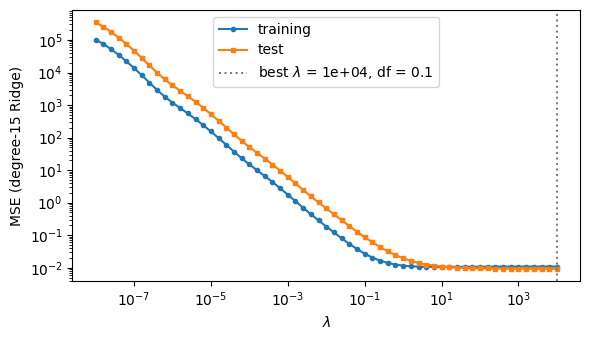

best Ridge test MSE 0.00928 at lambda 1e+04 (effective dof 0.10; best OLS degree above was 1)
[2.75037747e+01 1.48650338e+01 7.02527582e+00 4.16167882e+00
 2.11415536e+00 1.04620806e+00 5.22298297e-01 2.24950641e-01
 9.97205206e-02 3.54972635e-02 1.57898431e-02 4.38314749e-03
 1.71315187e-03 3.47345662e-04 1.31579578e-04]


In [ ]:
d = 15
Xtr = np.vander(x_train.flatten(), d + 1, increasing=True) # lager designmatrise basert på input x
Xte = np.vander(x_test.flatten(),  d + 1, increasing=True)
# standardise (fit on training data only!), centre y
mu, sd = Xtr[:, 1:].mean(axis=0), Xtr[:, 1:].std(axis=0) # definerer mean og standard deviation basert på training data
Xtr_s, Xte_s = (Xtr[:, 1:] - mu) / sd, (Xte[:, 1:] - mu) / sd # standardiserer design matrisene
ym = y_train.mean()

lambdas = np.logspace(-8, 4, 61)
mse_tr_r, mse_te_r, dfs = [], [], []
s = np.linalg.svd(Xtr_s, compute_uv=False) # computes the singular values (sigma1, sigma2...) for the design matrix based on training data
for l in lambdas:
    theta = ridge_svd(Xtr_s, y_train - ym, l) # finner parametriseringen theta gitt en lambda
    mse_tr_r.append(MSE(y_train, ym + Xtr_s @ theta))
    mse_te_r.append(MSE(y_test,  ym + Xte_s @ theta))
    dfs.append(np.sum(s**2 / (s**2 + l)))          # effective degrees of freedom: how many parameters the model effectivly is using

best = int(np.argmin(mse_te_r)) # finds the index where the MSE is lowest for testing data - the same as degree corresponding to lowest MSE
plt.figure(figsize=(6, 3.5))
plt.plot(lambdas, mse_tr_r, "o-", ms=3, label="training")
plt.plot(lambdas, mse_te_r, "s-", ms=3, label="test")
plt.axvline(lambdas[best], color="gray", ls=":",
            label=rf"best $\lambda$ = {lambdas[best]:.2g}, df = {dfs[best]:.1f}")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\lambda$"); plt.ylabel("MSE (degree-15 Ridge)"); plt.legend()
plt.tight_layout(); plt.show()
print(f"best Ridge test MSE {mse_te_r[best]:.5f} at lambda {lambdas[best]:.3g} "
      f"(effective dof {dfs[best]:.2f}; best OLS degree above was {best_d})")


2.